### Import all packages need in the cell below

In [1]:
using JuMP, HiGHS, Ipopt
using Plots

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

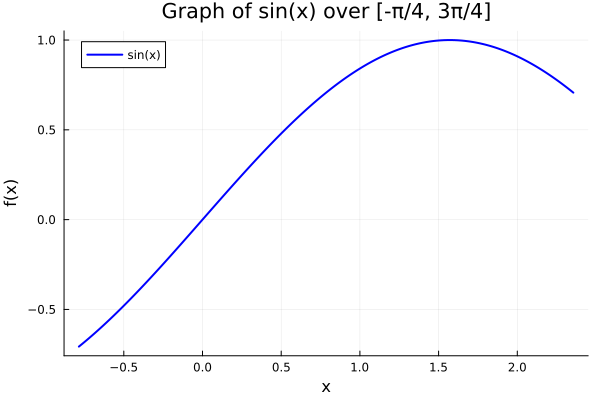

In [2]:
x = range(-π/4, stop=3π/4, length=500)
plot(x, sin.(x),
    label="sin(x)",
    xlabel="x",
    ylabel="f(x)",
    title="Graph of sin(x) over [-π/4, 3π/4]",
    lw=2,
    color=:blue)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

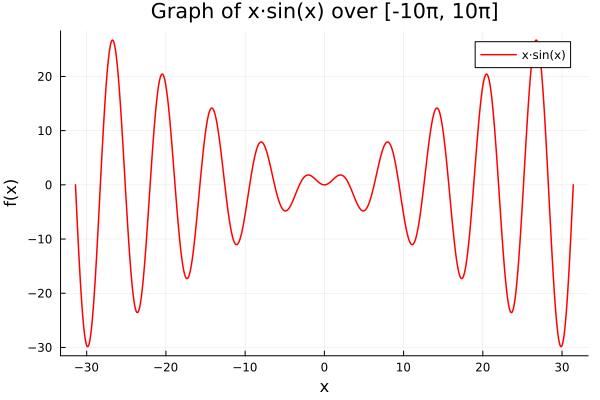

In [3]:
x = range(-10π, stop=10π, length=1000)
plot(x, x .* sin.(x),
    label="x·sin(x)",
    xlabel="x",
    ylabel="f(x)",
    title="Graph of x·sin(x) over [-10π, 10π]",
    lw=1.5,
    color=:red)

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [4]:
# ─── Data ────────────────────────────────────────────────────────────────────
N  = 10     # number of cylinders to fill
c1 = 2.0    # cost coefficient for top/bottom caps (area)
c2 = 0.5    # cost coefficient for lateral surface (area × volume interaction)

# ─── Model ───────────────────────────────────────────────────────────────────
# Objective: max N·π·r²·h - c1·π·r² - c2·π·r²·h·(π·r² + 2π·r·h)
# where the profit is a nonlinear function of radius r and height h.
model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, r >= 1e-4)   # cylinder radius
@variable(model, h >= 1e-4)   # cylinder height

# Nonlinear objective (negate for maximisation → use NLobjective as min -f)
@objective(model, Max,
    N * π * r^2 * h - c1 * π * r^2 - c2 * π * r^2 * h * (π * r^2 + 2π * r * h)
)

# Starting point
set_start_value(r, 1.0)
set_start_value(h, 1.0)

# ─── Solve ───────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status : ", termination_status(model))
println("Optimal radius r   : ", round(value(r), digits=4))
println("Optimal height h   : ", round(value(h), digits=4))
println("Optimal objective  : ", round(objective_value(model), digits=4))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Termination status : LOCALLY_SOLVED
Optimal radius r   : 0.8256
Optimal height h   : 1.7215
Optimal objective  : 12.1741


# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [5]:
# ─── Data ────────────────────────────────────────────────────────────────────
h_awn = 2.0   # minimum required height of the awning
w_awn = 3.0   # width of the awning

# ─── Model ───────────────────────────────────────────────────────────────────
# Find the shortest pole (x, y) such that the awning of width w at height h
# is fully covered. The pole tip is at (x, y); the constraint ensures the
# awning's far edge clears the required height h.
#
# min  √(x² + y²)   [pole length]
# s.t. y - (y/x)·w ≥ h        [awning geometry constraint]
#      x, y ≥ 0

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, x >= 1e-4)
@variable(model, y >= 1e-4)

# Objective: minimise pole length
@objective(model, Min, sqrt(x^2 + y^2))

# Awning geometry constraint
@constraint(model, y - (y / x) * w_awn >= h_awn)

# Starting point
set_start_value(x, 1.0)
set_start_value(y, 1.0)

# ─── Solve ───────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status    : ", termination_status(model))
println("Optimal x             : ", round(value(x), digits=4))
println("Optimal y             : ", round(value(y), digits=4))
println("Minimum pole length   : ", round(objective_value(model), digits=4))

Termination status    : LOCALLY_SOLVED
Optimal x             : 5.2894
Optimal y             : 4.6207
Minimum pole length   : 7.0235


# Problem Statement

Solve the Packing Problem

In [6]:
# ─── Model ───────────────────────────────────────────────────────────────────
# Maximise the volume of a box (w × h × d) subject to a material constraint:
#   2wh + 2dh + 6wd ≤ 60   (two side faces + two end faces + top & bottom with thicker material)
#   w, h, d ≥ 0

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, w >= 1e-4)   # width
@variable(model, h >= 1e-4)   # height
@variable(model, d >= 1e-4)   # depth

# Objective: maximise volume
@objective(model, Max, h * w * d)

# Material constraint
@constraint(model, 2w*h + 2d*h + 6w*d <= 60)

# Starting point
set_start_value(w, 2.0)
set_start_value(h, 5.0)
set_start_value(d, 2.0)

# ─── Solve ───────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status : ", termination_status(model))
println("Optimal width  w   : ", round(value(w), digits=4))
println("Optimal height h   : ", round(value(h), digits=4))
println("Optimal depth  d   : ", round(value(d), digits=4))
println("Maximum volume     : ", round(objective_value(model), digits=4))

Termination status : LOCALLY_SOLVED
Optimal width  w   : 1.8257
Optimal height h   : 5.4772
Optimal depth  d   : 1.8257
Maximum volume     : 18.2574


# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

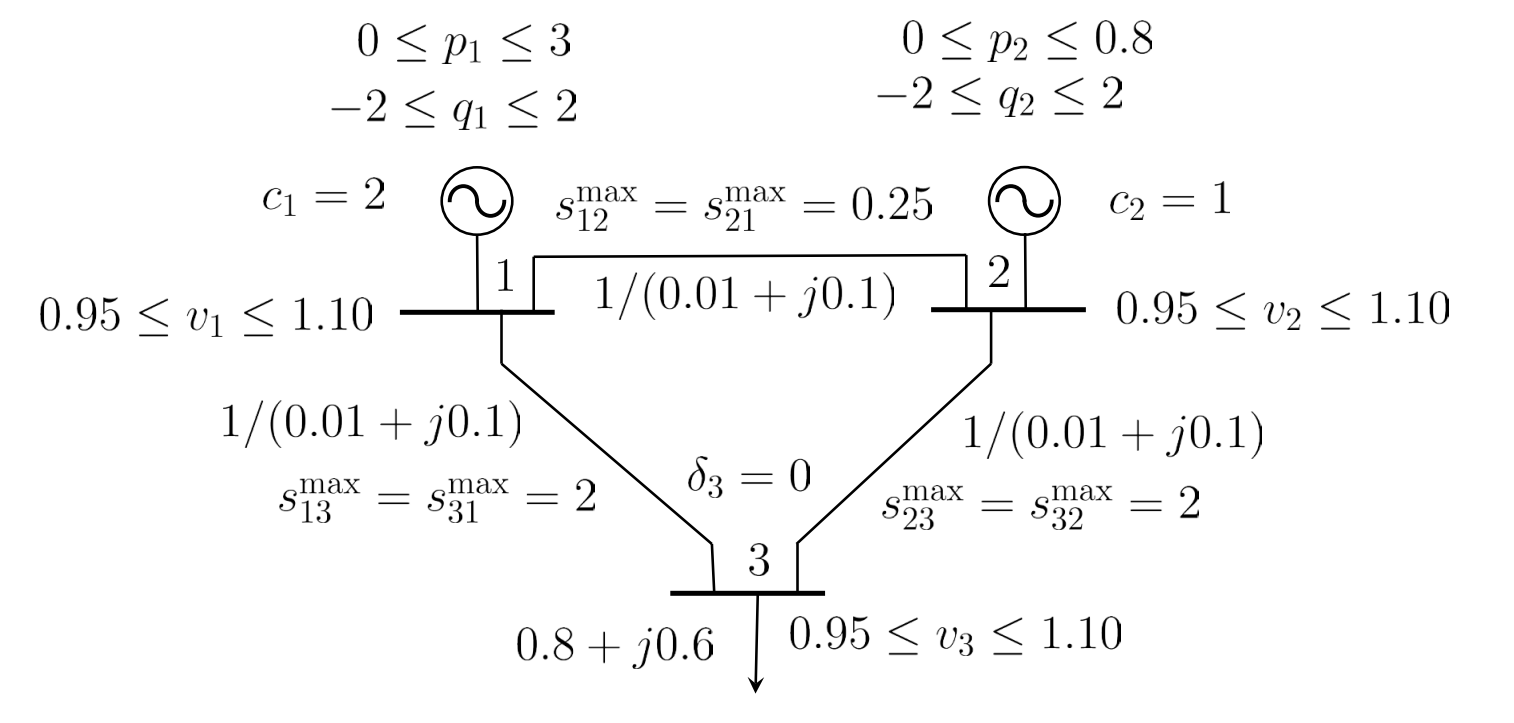

In [7]:
# ─── 3-Bus AC Optimal Power Flow ─────────────────────────────────────────────
#
# System data:
#   Bus 1: Generator (slack-like PV), c1=2, 0 ≤ p1 ≤ 3, -2 ≤ q1 ≤ 2, 0.95 ≤ v1 ≤ 1.10
#   Bus 2: Generator,                 c2=1, 0 ≤ p2 ≤ 0.8, -2 ≤ q2 ≤ 2, 0.95 ≤ v2 ≤ 1.10
#   Bus 3: Load (Pd=0.8, Qd=0.6), reference bus (δ3=0),              0.95 ≤ v3 ≤ 1.10
#
#   All lines: impedance z = 0.01 + j0.1, shunt = 0
#   Line flow limits: s12_max = s21_max = 0.25; s13 = s31 = s23 = s32 = 2.0
# ─────────────────────────────────────────────────────────────────────────────

# Line admittances (series only, no shunt)
z_line = 0.01 + 0.1im
y_line = 1 / z_line          # series admittance for each branch
g_L = real(y_line)
b_L = imag(y_line)

# Angle of admittance |Y|∠θ_Y
y_mag = abs(y_line)
θ_Y   = angle(y_line)        # arctan(b/g)

# Load data
Pd3 = 0.8; Qd3 = 0.6

# Generator cost coefficients
c1 = 2.0; c2 = 1.0

model = Model(Ipopt.Optimizer)
set_silent(model)

# ─── Decision Variables ───────────────────────────────────────────────────────
@variable(model, 0.0  <= p1 <= 3.0)       # active power gen 1
@variable(model, -2.0 <= q1 <= 2.0)       # reactive power gen 1
@variable(model, 0.0  <= p2 <= 0.8)       # active power gen 2
@variable(model, -2.0 <= q2 <= 2.0)       # reactive power gen 2

@variable(model, 0.95 <= v1 <= 1.10)      # voltage magnitude bus 1
@variable(model, 0.95 <= v2 <= 1.10)      # voltage magnitude bus 2
@variable(model, 0.95 <= v3 <= 1.10)      # voltage magnitude bus 3

@variable(model, δ1)                       # voltage angle bus 1
@variable(model, δ2)                       # voltage angle bus 2
@variable(model, δ3 == 0.0)               # reference bus angle fixed to 0

# ─── Objective ────────────────────────────────────────────────────────────────
@objective(model, Min, c1 * p1 + c2 * p2)

# ─── Power Flow Equations (AC, lossless shunt) ────────────────────────────────
# Active power injected at bus i:
#   Pi = vi² * Gii + Σ_{j≠i} vi*vj*(Gij*cos(δi-δj) + Bij*sin(δi-δj))
# For our Y-bus (no shunts):
#   Gii = g_L * (number of lines at bus i),  Gij = -g_L
#   Bii = b_L * (number of lines at bus i),  Bij = -b_L
#
# Lines: 1-2, 1-3, 2-3  (all with same admittance)

# Bus 1 power balance (generator - load = injection; bus 1 has no load)
@constraint(model, p1 == v1^2*(2g_L)
    + v1*v2*(-g_L*cos(δ1-δ2) - b_L*sin(δ1-δ2))   # to bus 2 (sign of sin: +Bij*sin = -b_L*sin)
    + v1*v3*(-g_L*cos(δ1-δ3) - b_L*sin(δ1-δ3)))   # to bus 3

# Wait — standard sign convention for Bij in Y-bus with series admittance g+jb:
# Yij = -(g_L + jb_L), so Gij=-g_L, Bij=-b_L
# Pij = vi*vj*(Gij*cos(δij)+Bij*sin(δij))
# Pi  = vi²*Gii + Σ vi*vj*(Gij*cos+Bij*sin)   with Gii=Σ|Gij|=2g_L

@constraint(model, q1 == -v1^2*(2b_L)
    + v1*v2*(b_L*cos(δ1-δ2) - g_L*sin(δ1-δ2))
    + v1*v3*(b_L*cos(δ1-δ3) - g_L*sin(δ1-δ3)))

# Bus 2 power balance (generator only, no load)
@constraint(model, p2 == v2^2*(2g_L)
    + v2*v1*(-g_L*cos(δ2-δ1) - b_L*sin(δ2-δ1))
    + v2*v3*(-g_L*cos(δ2-δ3) - b_L*sin(δ2-δ3)))

@constraint(model, q2 == -v2^2*(2b_L)
    + v2*v1*(b_L*cos(δ2-δ1) - g_L*sin(δ2-δ1))
    + v2*v3*(b_L*cos(δ2-δ3) - g_L*sin(δ2-δ3)))

# Bus 3 power balance (load only, no generator)
@constraint(model, -Pd3 == v3^2*(2g_L)
    + v3*v1*(-g_L*cos(δ3-δ1) - b_L*sin(δ3-δ1))
    + v3*v2*(-g_L*cos(δ3-δ2) - b_L*sin(δ3-δ2)))

@constraint(model, -Qd3 == -v3^2*(2b_L)
    + v3*v1*(b_L*cos(δ3-δ1) - g_L*sin(δ3-δ1))
    + v3*v2*(b_L*cos(δ3-δ2) - g_L*sin(δ3-δ2)))

# ─── Line Flow Limits (apparent power) ───────────────────────────────────────
# Active power flow from i to j: pij = vi²*g_L - vi*vj*(g_L*cos(δij)+b_L*sin(δij))
# Reactive power flow:           qij = -vi²*b_L + vi*vj*(b_L*cos(δij)-g_L*sin(δij))
# |sij|² = pij² + qij² ≤ smax²

# Line 1-2  (smax = 0.25 pu)
p12 = @expression(model, v1^2*g_L - v1*v2*(g_L*cos(δ1-δ2) + b_L*sin(δ1-δ2)))
q12 = @expression(model, -v1^2*b_L + v1*v2*(b_L*cos(δ1-δ2) - g_L*sin(δ1-δ2)))
p21 = @expression(model, v2^2*g_L - v2*v1*(g_L*cos(δ2-δ1) + b_L*sin(δ2-δ1)))
q21 = @expression(model, -v2^2*b_L + v2*v1*(b_L*cos(δ2-δ1) - g_L*sin(δ2-δ1)))
@constraint(model, p12^2 + q12^2 <= 0.25^2)
@constraint(model, p21^2 + q21^2 <= 0.25^2)

# Lines 1-3 and 2-3 (smax = 2.0 pu — non-binding in practice)
p13 = @expression(model, v1^2*g_L - v1*v3*(g_L*cos(δ1-δ3) + b_L*sin(δ1-δ3)))
q13 = @expression(model, -v1^2*b_L + v1*v3*(b_L*cos(δ1-δ3) - g_L*sin(δ1-δ3)))
p23 = @expression(model, v2^2*g_L - v2*v3*(g_L*cos(δ2-δ3) + b_L*sin(δ2-δ3)))
q23 = @expression(model, -v2^2*b_L + v2*v3*(b_L*cos(δ2-δ3) - g_L*sin(δ2-δ3)))
@constraint(model, p13^2 + q13^2 <= 2.0^2)
@constraint(model, p23^2 + q23^2 <= 2.0^2)

# ─── Starting Point ───────────────────────────────────────────────────────────
set_start_value(v1, 1.0); set_start_value(v2, 1.0); set_start_value(v3, 1.0)
set_start_value(δ1, 0.0); set_start_value(δ2, 0.0)
set_start_value(p1, 0.5); set_start_value(p2, 0.5)
set_start_value(q1, 0.0); set_start_value(q2, 0.0)

# ─── Solve ────────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status : ", termination_status(model))
println("Optimal cost       : ", round(objective_value(model), digits=4))
println()
println("─── Generators ───")
println("  p1 = $(round(value(p1),digits=4))  q1 = $(round(value(q1),digits=4))")
println("  p2 = $(round(value(p2),digits=4))  q2 = $(round(value(q2),digits=4))")
println()
println("─── Voltages ───")
println("  Bus 1: v=$(round(value(v1),digits=4)) pu,  δ=$(round(rad2deg(value(δ1)),digits=3))°")
println("  Bus 2: v=$(round(value(v2),digits=4)) pu,  δ=$(round(rad2deg(value(δ2)),digits=3))°")
println("  Bus 3: v=$(round(value(v3),digits=4)) pu,  δ=$(round(rad2deg(value(δ3)),digits=3))°")

Termination status : LOCALLY_SOLVED
Optimal cost       : 0.8361

─── Generators ───
  p1 = 0.0309  q1 = 0.3209
  p2 = 0.7743  q2 = 0.3308

─── Voltages ───
  Bus 1: v=1.0977 pu,  δ=1.217°
  Bus 2: v=1.1 pu,  δ=2.401°
  Bus 3: v=1.0664 pu,  δ=0.0°


# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [8]:
# ─── Data ────────────────────────────────────────────────────────────────────
# Design matrix X (with intercept column) and response vector y
# Each row: [1, x1, x2, x3]
X = [1.0  1.0  0.5  1.2;
     1.0  2.0  1.0  2.1;
     1.0  3.0  1.5  2.9;
     1.0  4.0  2.0  3.8;
     1.0  5.0  2.5  4.5]

y = [2.0, 3.9, 6.1, 8.0, 9.8]

# ─── Least Squares via QP (JuMP / HiGHS) ─────────────────────────────────────
# min  ‖y - Xβ‖²  =  Σ (yi - [Xβ]_i)²
# Variables: β = [β0, β1, β2, β3]

model = Model(Ipopt.Optimizer)
set_silent(model)

n, p = size(X)          # 5 observations, 4 parameters (intercept + 3 features)
@variable(model, β[1:p])

@objective(model, Min, sum((y[i] - sum(X[i,k]*β[k] for k in 1:p))^2 for i in 1:n))

optimize!(model)

β_opt = value.(β)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status : ", termination_status(model))
println()
println("─── Estimated Coefficients ───")
println("  β0 (intercept) = ", round(β_opt[1], digits=6))
println("  β1             = ", round(β_opt[2], digits=6))
println("  β2             = ", round(β_opt[3], digits=6))
println("  β3             = ", round(β_opt[4], digits=6))
println()

# Predicted values and residuals
println("─── Fitted Values vs Observed ───")
for i in 1:n
    ŷ = sum(X[i,k]*β_opt[k] for k in 1:p)
    println("  obs $i: y=$(y[i]),  ŷ=$(round(ŷ,digits=4)),  residual=$(round(y[i]-ŷ,digits=6))")
end

println()
println("Sum of Squared Residuals (SSR) : ", round(objective_value(model), digits=8))

Termination status : LOCALLY_SOLVED

─── Estimated Coefficients ───
  β0 (intercept) = -0.285455
  β1             = 0.272424
  β2             = 2.036971
  β3             = 0.818182

─── Fitted Values vs Observed ───
  obs 1: y=2.0,  ŷ=1.9873,  residual=0.012727
  obs 2: y=3.9,  ŷ=4.0145,  residual=-0.114545
  obs 3: y=6.1,  ŷ=5.96,  residual=0.14
  obs 4: y=8.0,  ŷ=7.9873,  residual=0.012727
  obs 5: y=9.8,  ŷ=9.8509,  residual=-0.050909

Sum of Squared Residuals (SSR) : 0.03563636


# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [9]:
# ─── Data ────────────────────────────────────────────────────────────────────
# Capability scores S[i,j]: score of designer i on project j
S = [90 80 10 50;
     60 70 50 65;
     70 40 80 85]

r       = [70, 50, 85, 35]   # required hours for each project
H_max   = 80                  # maximum hours available per designer

designers = 1:3
projects  = 1:4

# ─── Model ───────────────────────────────────────────────────────────────────
model = Model(HiGHS.Optimizer)
set_silent(model)   # suppress solver output

# Decision variables: H[i,j] = hours designer i allocates to project j
@variable(model, H[designers, projects] >= 0)

# Objective: maximise total weighted contribution score
@objective(model, Max, sum(S[i,j] * H[i,j] for i in designers, j in projects))

# Constraint 1 – designer availability: each designer has at most 80 hours
@constraint(model, avail[i in designers],
    sum(H[i,j] for j in projects) <= H_max)

# Constraint 2 – project demand: each project must receive exactly its required hours
@constraint(model, demand[j in projects],
    sum(H[i,j] for i in designers) == r[j])

# ─── Solve ───────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status : ", termination_status(model))
println("Optimal objective  : ", round(objective_value(model), digits=2))

println("\n─── Optimal Allocation H[i,j] (hours) ───")
header = "          " * join(["Proj $j" for j in projects], "  ")
println(header)
for i in designers
    row = "Designer $i │ " * join([lpad(round(value(H[i,j]), digits=1), 6) for j in projects], "  ")
    println(row)
end

println("\n─── Hours used per designer ───")
for i in designers
    used = sum(value(H[i,j]) for j in projects)
    println("  Designer $i: $(round(used, digits=1)) / $H_max hours")
end

println("\n─── Hours delivered per project ───")
for j in projects
    delivered = sum(value(H[i,j]) for i in designers)
    println("  Project $j: $(round(delivered, digits=1)) / $(r[j]) hours required")
end

Termination status : OPTIMAL
Optimal objective  : 18825.0

─── Optimal Allocation H[i,j] (hours) ───
          Proj 1  Proj 2  Proj 3  Proj 4
Designer 1 │   70.0    10.0     0.0     0.0
Designer 2 │    0.0    40.0     5.0    35.0
Designer 3 │    0.0     0.0    80.0     0.0

─── Hours used per designer ───
  Designer 1: 80.0 / 80 hours
  Designer 2: 80.0 / 80 hours
  Designer 3: 80.0 / 80 hours

─── Hours delivered per project ───
  Project 1: 70.0 / 70 hours required
  Project 2: 50.0 / 50 hours required
  Project 3: 85.0 / 85 hours required
  Project 4: 35.0 / 35 hours required


# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [10]:
# ─── Data ────────────────────────────────────────────────────────────────────
# Food items: Apple, Bread, Milk, Egg
cost     = [1.0,  0.50, 2.0,  0.30]   # cost per unit ($)
calories = [100,  200,  150,  70  ]   # calories per unit
protein  = [0.5,  4.0,  8.0,  6.0 ]   # protein (g) per unit
vitamins = [2.0,  0.0,  10.0, 0.0 ]   # vitamins (% daily) per unit

# Daily nutritional requirements
cal_min  = 500.0   # calories
prot_min = 50.0    # protein (g)
vit_min  = 100.0   # vitamins (% daily)

foods = 1:4

# ─── Model ───────────────────────────────────────────────────────────────────
model = Model(HiGHS.Optimizer)
set_silent(model)

@variable(model, y[foods] >= 0)   # quantity of each food item

# Objective: minimise total cost
@objective(model, Min, sum(cost[j] * y[j] for j in foods))

# Nutritional constraints
@constraint(model, cal_con,  sum(calories[j] * y[j] for j in foods) >= cal_min)
@constraint(model, prot_con, sum(protein[j]  * y[j] for j in foods) >= prot_min)
@constraint(model, vit_con,  sum(vitamins[j] * y[j] for j in foods) >= vit_min)

# ─── Solve ───────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
food_names = ["Apple", "Bread", "Milk", "Egg"]
println("Termination status : ", termination_status(model))
println("Minimum diet cost  : \$", round(objective_value(model), digits=4))
println()
println("─── Optimal Quantities ───")
for j in foods
    qty = round(value(y[j]), digits=4)
    if qty > 1e-6
        println("  $(food_names[j]): $qty units")
    end
end
println()
println("─── Nutritional Check ───")
println("  Calories : ", round(sum(calories[j]*value(y[j]) for j in foods), digits=2), " / $cal_min  required")
println("  Protein  : ", round(sum(protein[j] *value(y[j]) for j in foods), digits=2), "g / $prot_min g required")
println("  Vitamins : ", round(sum(vitamins[j]*value(y[j]) for j in foods), digits=2), "% / $vit_min% required")

Termination status : OPTIMAL
Minimum diet cost  : $20.0

─── Optimal Quantities ───
  Milk: 10.0 units

─── Nutritional Check ───
  Calories : 1500.0 / 500.0  required
  Protein  : 80.0g / 50.0 g required
  Vitamins : 100.0% / 100.0% required


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [11]:
# ─── Data ────────────────────────────────────────────────────────────────────
# Items: Tent, Stove, Food
item_names = ["Tent", "Stove", "Food"]
values     = [120,  80,  60]    # value ($)
weights    = [2.0,  1.0, 1.0]   # weight (kg)
capacity   = 3.5                # backpack capacity (kg)

items = 1:3

# ─── Model ───────────────────────────────────────────────────────────────────
model = Model(HiGHS.Optimizer)
set_silent(model)

# Binary decision variables: x[i] = 1 if item i is selected
@variable(model, x[items], Bin)

# Objective: maximise total value
@objective(model, Max, sum(values[i] * x[i] for i in items))

# Capacity constraint
@constraint(model, weight_con, sum(weights[i] * x[i] for i in items) <= capacity)

# ─── Solve ───────────────────────────────────────────────────────────────────
optimize!(model)

# ─── Results ─────────────────────────────────────────────────────────────────
println("Termination status   : ", termination_status(model))
println("Maximum value        : \$", round(objective_value(model), digits=2))
println()
println("─── Selected Items ───")
total_weight = 0.0
for i in items
    if value(x[i]) > 0.5
        println("  ✓ $(item_names[i])  (value=\$$(values[i]), weight=$(weights[i])kg)")
        global total_weight += weights[i]
    else
        println("  ✗ $(item_names[i])")
    end
end
println()
println("Total weight used : $(total_weight)kg / $(capacity)kg capacity")

Termination status   : OPTIMAL
Maximum value        : $200.0

─── Selected Items ───
  ✓ Tent  (value=$120, weight=2.0kg)
  ✓ Stove  (value=$80, weight=1.0kg)
  ✗ Food

Total weight used : 3.0kg / 3.5kg capacity


# Problem Statement 1.2 — Proofs of Convexity and Concavity

Prove the following results using the **definition** of convex functions and the **first/second-order characterizations**.

---

## (a) Univariate Functions

### Exponential: $e^{ax}$ is convex for any $a$ over $\mathbb{R}$

**Proof (second-order condition).**

Let $f(x) = e^{ax}$.  
Then $f''(x) = a^2 e^{ax}$.  
Since $e^{ax} > 0$ for all $x \in \mathbb{R}$ and $a^2 \geq 0$, we have $f''(x) \geq 0$ for all $x$.  
By the second-order condition, $f$ is **convex**. $\blacksquare$

---

### Power function: $x^a$ is convex for $a \geq 1$ or $a \leq 0$ over $\mathbb{R}_+$

**Proof (second-order condition).**

Let $f(x) = x^a$ for $x > 0$.  
Then $f''(x) = a(a-1)\, x^{a-2}$.  
Since $x > 0$, we have $x^{a-2} > 0$, so the sign of $f''$ is determined by $a(a-1)$:

- If $a \geq 1$: $a > 0$ and $a - 1 \geq 0$, so $a(a-1) \geq 0$.  
- If $a \leq 0$: $a \leq 0$ and $a - 1 < 0$, so $a(a-1) \geq 0$.

In both cases $f''(x) \geq 0$, hence $f$ is **convex** on $\mathbb{R}_+$. $\blacksquare$

---

### Power function: $x^a$ is concave for $0 \leq a \leq 1$ over $\mathbb{R}_+$

**Proof (second-order condition).**

As above, $f''(x) = a(a-1)\, x^{a-2}$.  
For $0 \leq a \leq 1$: $a \geq 0$ and $a - 1 \leq 0$, so $a(a-1) \leq 0$.  
Hence $f''(x) \leq 0$ for all $x > 0$, meaning $f$ is **concave** on $\mathbb{R}_+$. $\blacksquare$

---

### Logarithm: $\log x$ is concave over $\mathbb{R}_{++}$

**Proof (second-order condition).**

Let $f(x) = \log x$ for $x > 0$.  
Then $f'(x) = \frac{1}{x}$ and $f''(x) = -\frac{1}{x^2} < 0$ for all $x > 0$.  
Hence $f$ is **concave** on $\mathbb{R}_{++}$. $\blacksquare$

---

## (b) Affine Function: $f(x) = a^T x + b$ is both convex and concave

**Proof (definition).**

Let $x, y \in \mathbb{R}^n$ and $\theta \in [0, 1]$. Then:

$$
f(\theta x + (1-\theta) y)
= a^T(\theta x + (1-\theta) y) + b
= \theta a^T x + (1-\theta) a^T y + \theta b + (1-\theta) b
= \theta f(x) + (1-\theta) f(y).
$$

The convexity inequality $f(\theta x + (1-\theta) y) \leq \theta f(x) + (1-\theta) f(y)$ holds **with equality**, so $f$ is convex.  
The concavity inequality also holds with equality, so $f$ is concave.  
Therefore $f$ is **both convex and concave**. $\blacksquare$

---

## (c) Quadratic Function: $f(x) = \tfrac{1}{2}x^T Q x + b^T x + c$ is convex if $Q \succeq 0$

**Proof (second-order condition).**

Computing the gradient:
$$\nabla f(x) = Qx + b.$$

Computing the Hessian:
$$\nabla^2 f(x) = Q.$$

Since $Q \succeq 0$ by hypothesis, the Hessian is positive semidefinite everywhere.  
By the second-order condition, $f$ is **convex**. $\blacksquare$

---

## (d) Least Squares Loss: $f(x) = \|y - Ax\|_2^2$ is always convex

**Proof (second-order condition).**

Expand the objective:
$$
f(x) = (y - Ax)^T(y - Ax) = y^T y - 2(Ax)^T y + x^T A^T A x.
$$

The Hessian of $f$ is:
$$\nabla^2 f(x) = 2 A^T A.$$

For any vector $v \in \mathbb{R}^n$:
$$
v^T (A^T A) v = (Av)^T (Av) = \|Av\|_2^2 \geq 0.
$$

Hence $A^T A \succeq 0$, and therefore $2 A^T A \succeq 0$.  
By the second-order condition, $f$ is **convex** for any matrix $A$. $\blacksquare$